# Caderno 04: Análise Exploratória de Dados (EDA)

**Objetivo:** Responder descritivamente às quatro perguntas de pesquisa com tabelas e visualizações.

| RQ | Pergunta | Seções |
|---|---|---|
| RQ1 | Quais categorias concentram o maior volume? | 4.1 Tabela · 4.2 Figura |
| RQ2 | Grupos de senadores com perfis distintos? | 4.3 Tabela · 4.4 Figura · 4.5 Top Fornecedores |
| RQ3 | Despesas que desviam da média da categoria? | 4.6 Resumo · 4.7 Figura · 4.8 Top 20 |
| RQ4 | Evolução temporal ao longo de 5 anos? | 4.9 Série · 4.10 Pandemia · 4.11 Sazonalidade |

---
## Configuração

In [1]:
import pandas as pd
import sqlite3
import json
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT_DIR    = Path().resolve().parent
DB_PATH     = ROOT_DIR / 'database' / 'ceap.db'
FIGURES_DIR = ROOT_DIR / 'figures'
LOGS_DIR    = ROOT_DIR / 'logs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sys.path.append(str(ROOT_DIR))

from src.eda import (
    rq1_categorias,       plot_rq1,
    rq2_senadores,        plot_rq2,
    rq2_top_fornecedores, plot_rq2_fornecedores,
    rq3_anomalias,        plot_rq3,
    rq4_serie_temporal,   plot_rq4,
    rq4_pandemia,         plot_rq4_pandemia,
    rq4_sazonalidade,     plot_rq4_sazonalidade,
)

conn = sqlite3.connect(DB_PATH)
df   = pd.read_sql('SELECT * FROM features_ceap', conn, parse_dates=['data_despesa'])
conn.close()

df = df[(df['ano'] >= 2019) & (df['ano'] <= 2023)].copy()

for col in ['ano', 'mes', 'cod_senador']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
df['iqr_outlier_flag']  = df['iqr_outlier_flag'].astype(bool)
df['anomalia_consenso'] = df['anomalia_consenso'].astype(bool)

print(f'Registros : {len(df):,}')
print(f'Senadores : {df["cod_senador"].nunique()}')
print(f'Gasto total: R${df["valor_limpo"].sum():,.2f}')

eda_log = {}

Registros : 88,111
Senadores : 176
Gasto total: R$127,091,776.33


---
## RQ1 - Quais categorias de despesa concentram o maior volume financeiro?

### 4.1 Tabela de categorias

`total` = soma da legislatura inteira | `percentual` = participação no total geral | `pct_acumulado` = percentual acumulado (base da curva de Pareto)

In [2]:
resumo_cat = rq1_categorias(df)

display(
    resumo_cat[[
        'rank', 'categoria', 'n_registros',
        'total', 'percentual', 'pct_acumulado',
        'media', 'mediana'
    ]].style.format({
        'total'        : 'R${:,.0f}',
        'percentual'   : '{:.1f}%',
        'pct_acumulado': '{:.1f}%',
        'media'        : 'R${:,.0f}',
        'mediana'      : 'R${:,.0f}',
    }).background_gradient(subset=['percentual'], cmap='Blues')
)

eda_log['rq1_tabela'] = resumo_cat.to_dict('records')

,rank,categoria,n_registros,total,percentual,pct_acumulado,media,mediana
0,1,"CONTRATAÇÃO DE CONSULTORIAS, ASSESSORIAS, PESQUISAS, TRABALHOS TÉCNICOS E OUTROS SERVIÇOS DE APOIO AO EXERCÍCIO DO MANDATO PARLAMENTAR",5988,"R$31,575,626",24.8%,24.8%,"R$5,273","R$2,000"
1,2,"PASSAGENS AÉREAS, AQUÁTICAS E TERRESTRES NACIONAIS",17969,"R$28,307,701",22.3%,47.1%,"R$1,575","R$1,425"
2,3,"LOCOMOÇÃO, HOSPEDAGEM, ALIMENTAÇÃO, COMBUSTÍVEIS E LUBRIFICANTES",33062,"R$24,340,259",19.1%,66.3%,R$736,R$200
3,4,"ALUGUEL DE IMÓVEIS PARA ESCRITÓRIO POLÍTICO, COMPREENDENDO DESPESAS CONCERNENTES A ELES.",18747,"R$20,562,585",16.2%,82.4%,"R$1,097",R$391
4,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,5855,"R$17,172,289",13.5%,96.0%,"R$2,933","R$1,500"
5,6,"AQUISIÇÃO DE MATERIAL DE CONSUMO PARA USO NO ESCRITÓRIO POLÍTICO, INCLUSIVE AQUISIÇÃO OU LOCAÇÃO DE SOFTWARE, DESPESAS POSTAIS, AQUISIÇÃO DE PUBLICAÇÕES, LOCAÇÃO DE MÓVEIS E DE EQUIPAMENTOS.",6267,"R$4,766,685",3.8%,99.7%,R$761,R$205
6,7,NAO_INFORMADO,97,"R$224,605",0.2%,99.9%,"R$2,316","R$3,500"
7,8,SERVIÇOS DE SEGURANÇA PRIVADA,126,"R$142,027",0.1%,100.0%,"R$1,127",R$440


### 4.2 Figura RQ1 - Volume total e Curva de Pareto

**Painel esquerdo:** barras horizontais por categoria, percentual anotado. Top 3 em vermelho.

**Painel direito:** curva de Pareto — a linha vermelha cruza o limiar de 80% na categoria marcada com a linha pontilhada. Responde diretamente: *quantas categorias = 80% do gasto total?*

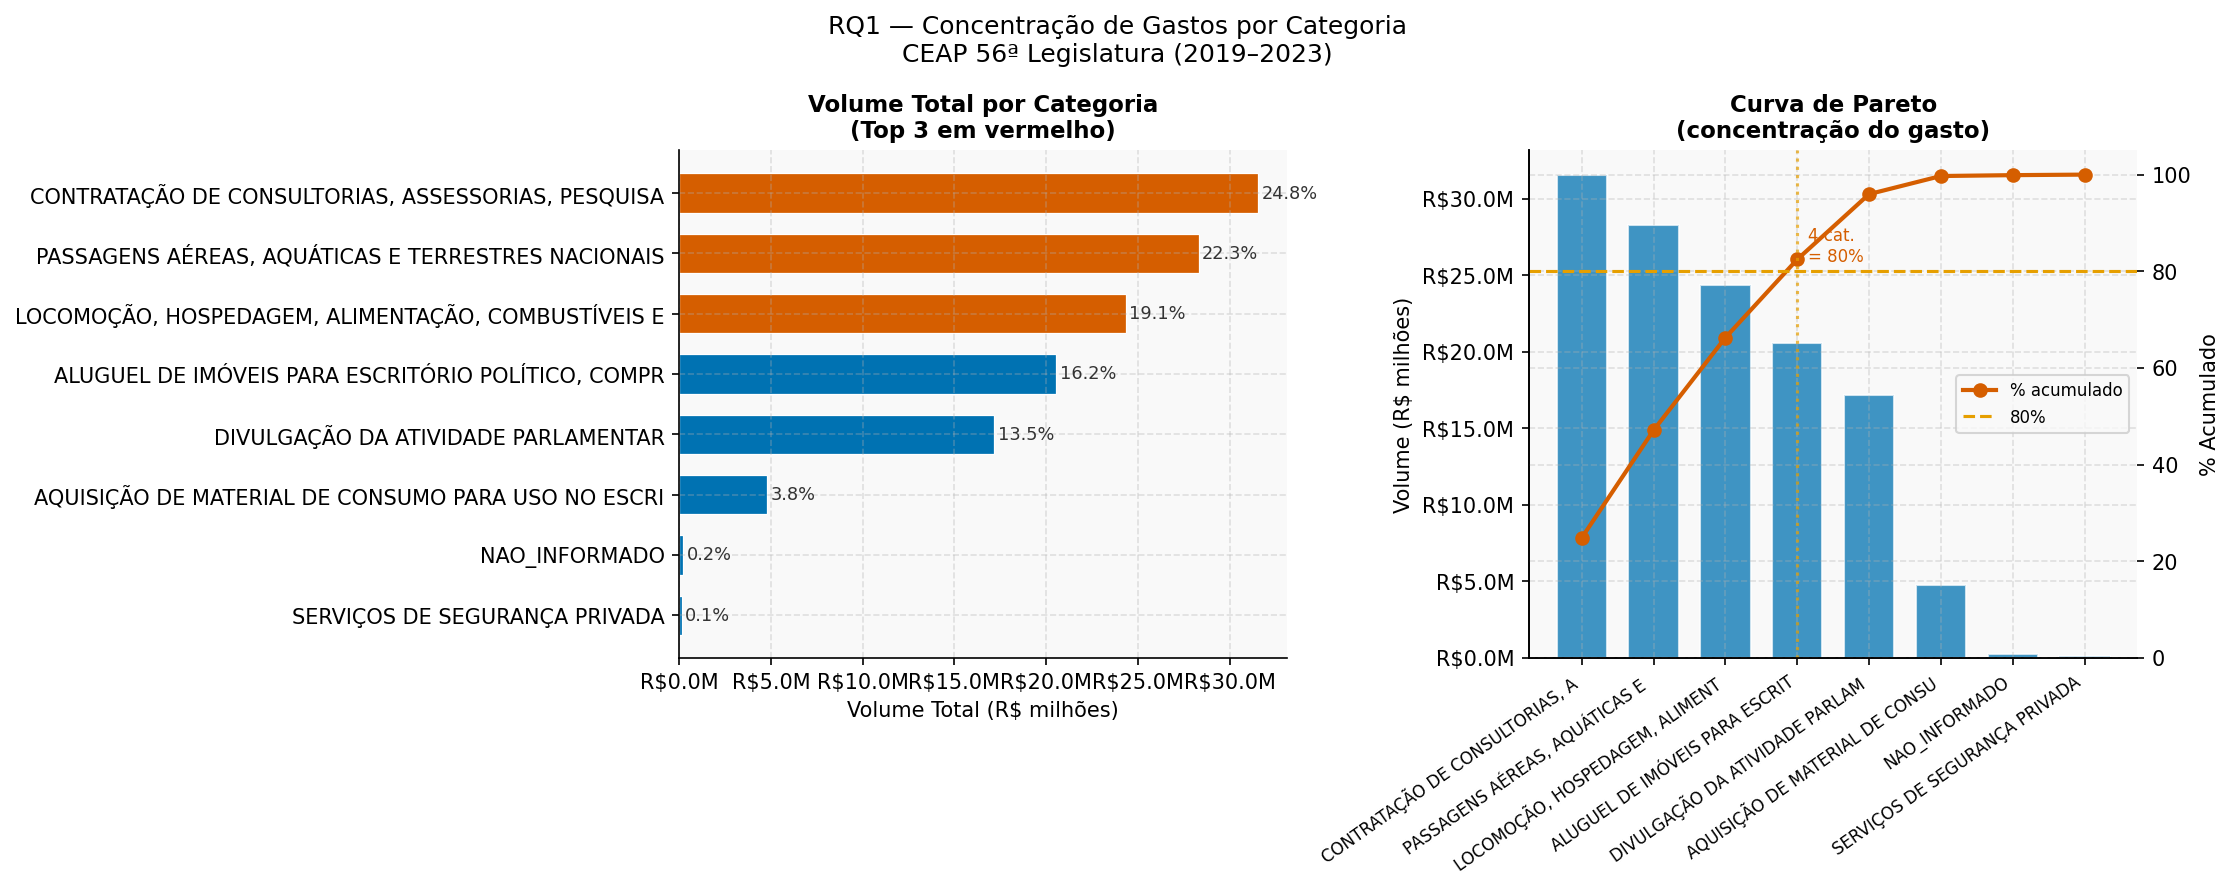

4 categoria(s) concentram 80% do gasto total.
Top 3 categorias: 66.3% do total.


In [3]:
import matplotlib.pyplot as plt

fig1, stats1 = plot_rq1(df, FIGURES_DIR)
eda_log['rq1'] = {k: v for k, v in stats1.items() if k != 'tabela'}
plt.show()

print(f"{stats1['n_categorias_80pct']} categoria(s) concentram 80% do gasto total.")
print(f"Top 3 categorias: {stats1['top3_pct']:.1f}% do total.")

---
## RQ2 - É possível identificar grupos de senadores com perfis de gasto distintos?

### 4.3 Tabela de perfil por senador (top 20)

`proporcao_maior_fornecedor` próximo de 1 = quase todo gasto em um único CNPJ. `n_fornecedores_distintos` baixo combinado com gasto alto = perfil de concentração.

In [4]:
perfil = rq2_senadores(df)
print(f'Total de senadores unicos: {len(perfil)}')

display(
    perfil.head(20)[[
        'rank', 'nome', 'total',
        'n_fornecedores_distintos', 'n_categorias_distintas',
        'proporcao_maior_categoria', 'proporcao_maior_fornecedor'
    ]].style.format({
        'total'                     : 'R${:,.0f}',
        'proporcao_maior_categoria' : '{:.3f}',
        'proporcao_maior_fornecedor': '{:.3f}',
    })
    .background_gradient(subset=['total'],                       cmap='Blues')
    .background_gradient(subset=['proporcao_maior_fornecedor'],  cmap='Reds')
)

eda_log['rq2_tabela'] = perfil.head(20).to_dict('records')

Total de senadores unicos: 176


,rank,nome,total,n_fornecedores_distintos,n_categorias_distintas,proporcao_maior_categoria,proporcao_maior_fornecedor
0,1,ROGÉRIO CARVALHO,"R$2,467,718",158,6,0.290,0.253
1,2,MECIAS DE JESUS,"R$2,426,284",42,6,0.309,0.218
2,3,DAVI ALCOLUMBRE,"R$2,197,553",25,6,0.645,0.156
3,4,OMAR AZIZ,"R$2,188,714",11,3,0.628,0.439
4,5,ZEQUINHA MARINHO,"R$2,164,687",345,6,0.350,0.338
5,6,ELIZIANE GAMA,"R$2,161,747",43,6,0.377,0.133
6,7,CHICO RODRIGUES,"R$2,141,571",42,6,0.367,0.243
7,8,MARCIO BITTAR,"R$2,124,237",52,6,0.532,0.213
8,9,LUCAS BARRETO,"R$2,106,478",43,6,0.274,0.260
9,10,EDUARDO BRAGA,"R$2,103,188",39,4,0.749,0.620


### 4.4 Figura RQ2 - Ranking e scatter de perfis

**Painel esquerdo:** top 20 senadores por gasto total. Top 5 em vermelho.

**Painel direito:** cada ponto é um senador. Eixo X = diversidade de fornecedores; eixo Y = gasto total. A cor vai do azul (gasto distribuído em muitos CNPJs) ao vermelho (concentrado em poucos). Pontos no canto superior esquerdo — alto gasto, poucos fornecedores, cor vermelha — são os perfis que o clustering (Caderno 05) deve isolar.

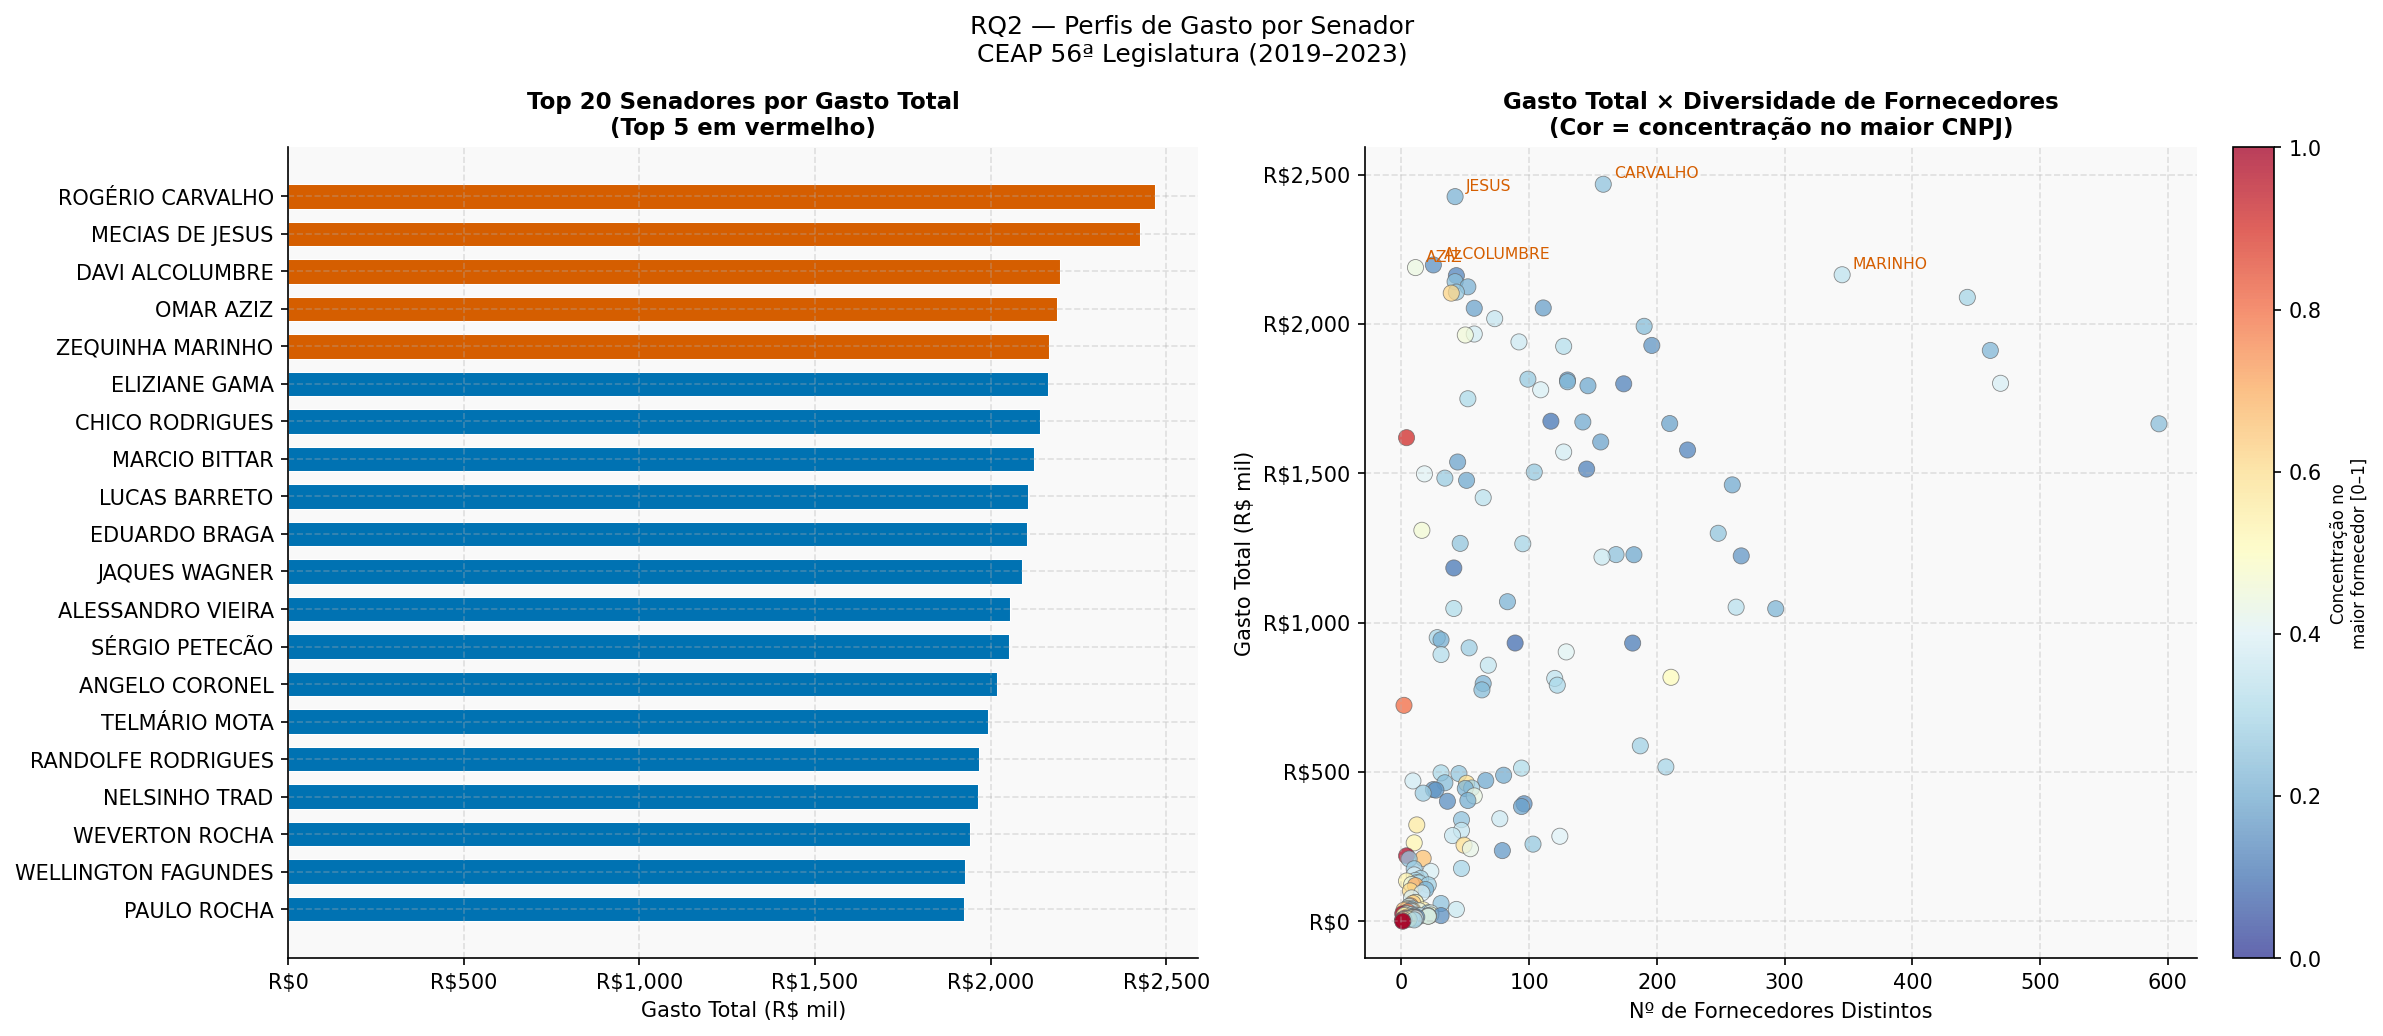

Top 5 senadores: 9.0% do gasto total da legislatura.
Media por senador : R$722,112.37
Mediana por senador: R$412,114.87


In [5]:
fig2, stats2 = plot_rq2(df, FIGURES_DIR)
eda_log['rq2'] = stats2
plt.show()

print(f"Top 5 senadores: {stats2['top5_pct_total']:.1f}% do gasto total da legislatura.")
print(f"Media por senador : R${stats2['media_por_senador']:,.2f}")
print(f"Mediana por senador: R${stats2['mediana_por_senador']:,.2f}")

### 4.5 Top 15 Fornecedores

`n_senadores` = quantos senadores distintos contrataram aquele fornecedor. Linhas em vermelho (fundo rosa na tabela, barra vermelha na figura) = fornecedor recebeu alto volume de **3 ou menos** senadores. Esse padrão de alto valor e poucos contratantes é um tentativa direta para a análise de anomalias (RQ3).

In [6]:
top_forn = rq2_top_fornecedores(df, n=15)

display(
    top_forn[[
        'rank', 'nome_fornecedor_limpo', 'total',
        'n_registros', 'n_senadores', 'percentual'
    ]].style.format({
        'total'     : 'R${:,.0f}',
        'percentual': '{:.2f}%',
    })
    .background_gradient(subset=['total'], cmap='Blues')
    .apply(
        lambda row: ['background-color: #ffdddd' if row['n_senadores'] <= 3
                     else '' for _ in row],
        axis=1
    )
)

eda_log['rq2_top_fornecedores'] = top_forn.to_dict('records')

,rank,nome_fornecedor_limpo,total,n_registros,n_senadores,percentual
0,1,ADRIA VIAGENS E TURISMO LTDA,"R$4,805,650",3395,34,3.78%
1,2,LATAM,"R$3,408,243",2043,69,2.68%
2,3,AIRES TURISMO,"R$2,275,575",1797,35,1.79%
3,4,GOL,"R$1,984,357",1201,52,1.56%
4,5,BORA COMUNICAÇÃO E MARKETING DIGITAL LTDA,"R$1,475,000",59,1,1.16%
5,6,L COELHO SERRA,"R$1,305,000",51,1,1.03%
6,7,UPLINK ASSESSORIA E CONSULTORIA EMPRESARIAL EIRELI -ME,"R$960,000",32,1,0.76%
7,8,PARIMA LOCAÇÃO BOA VISTA LTDA,"R$893,100",83,2,0.70%
8,9,HOME MIX PRODUÇÃO E ASSESSORIA EM RADIODIFUSÃO S/S LTDA,"R$891,200",31,1,0.70%
9,10,AZUL,"R$837,459",601,31,0.66%


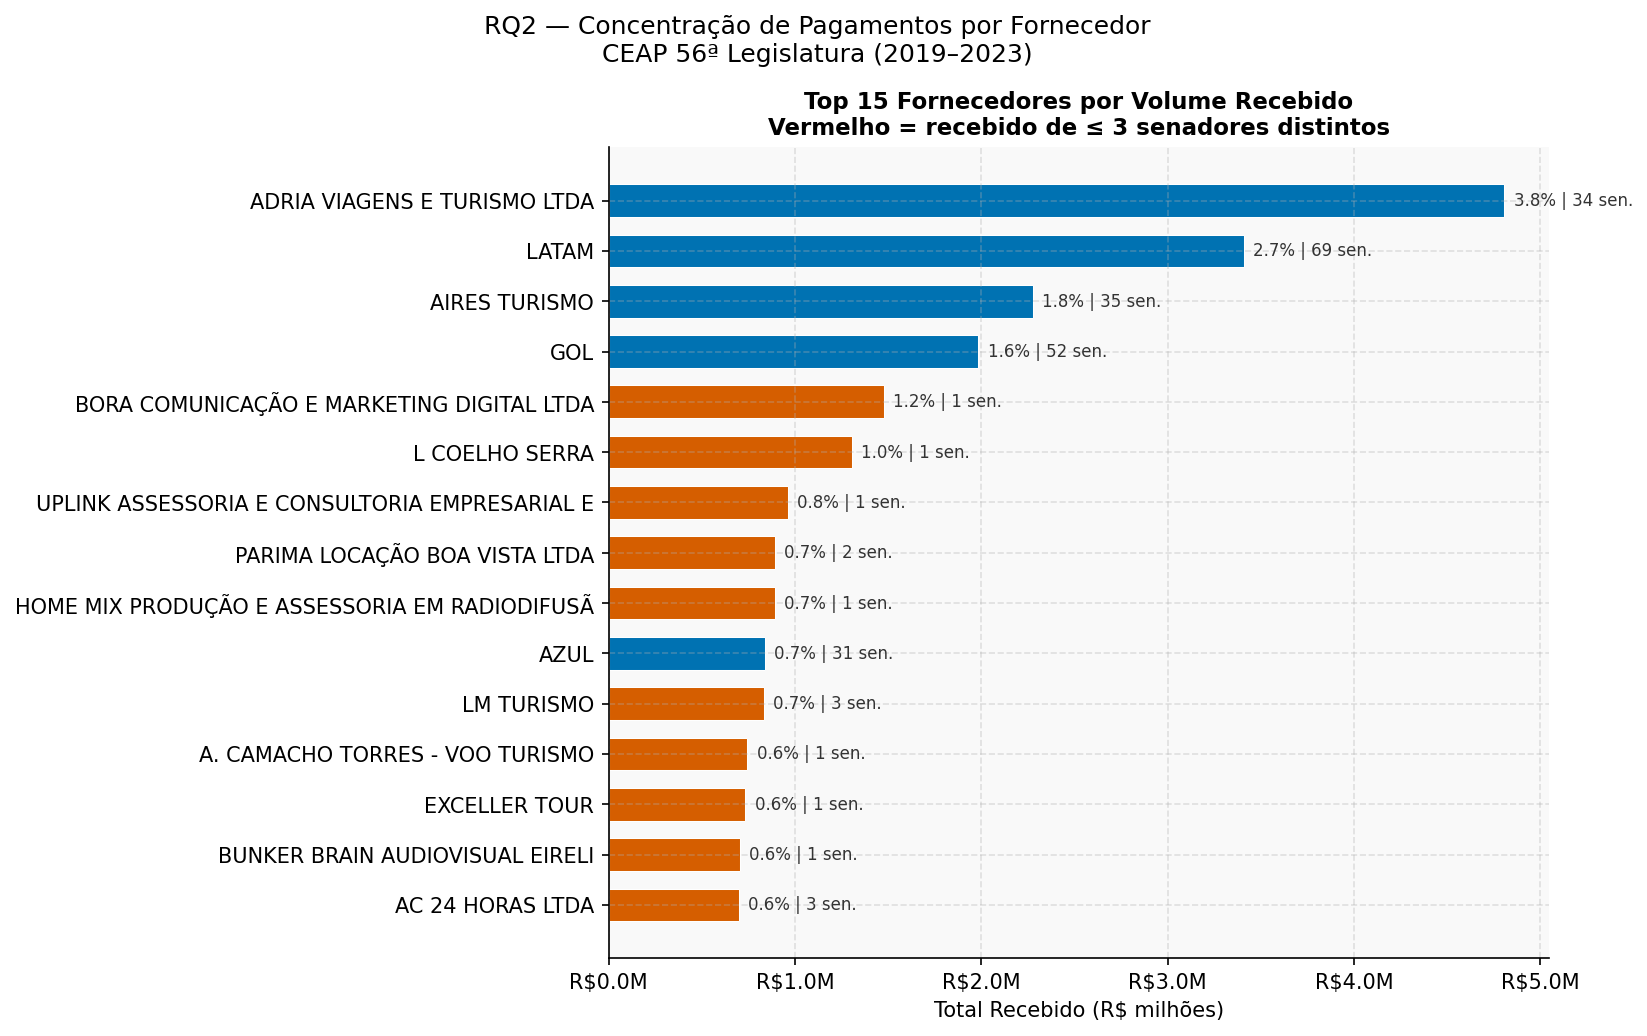

In [7]:
fig3, stats3 = plot_rq2_fornecedores(df, FIGURES_DIR)
eda_log['rq2_fornecedores'] = stats3
plt.show()

---
## RQ3 - Quais despesas se desviam significativamente do comportamento médio?

### 4.6 Resumo das anomalias detectadas

**Outlier IQR:** valor acima de Q3 + 1,5×IQR dentro da categoria (não-paramétrico).

**Anomalia de consenso:** outlier IQR *e* Z-score > 3 simultaneamente — evidência dupla.

In [8]:
res = rq3_anomalias(df)
eda_log['rq3_resumo'] = res

print(f"Total de registros              : {res['n_total']:>8,}")
print(f"Outliers IQR (por categoria)    : {res['n_outlier_iqr']:>8,}  ({res['pct_outlier_iqr']:.2f}%)")
print(f"Anomalias de consenso (Z + IQR) : {res['n_anomalia_consenso']:>8,}  ({res['pct_consenso']:.2f}%)")

Total de registros              :   88,111
Outliers IQR (por categoria)    :    9,803  (11.13%)
Anomalias de consenso (Z + IQR) :      127  (0.14%)


### 4.7 Figura RQ3 - Distribuição de valores e heatmap de anomalias

**Painel esquerdo:** histograma em escala original (azul) sobreposto ao `log(1+valor)` (laranja). O número no título mostra a redução da assimetria após a transformação, justificando por que o Z-score é calculado sobre o log.

**Painel direito:** heatmap de anomalias de consenso por categoria e ano. Célula vermelha isolada em um único ano = evento pontual. Distribuição uniforme ao longo dos anos = padrão sistemático da categoria.

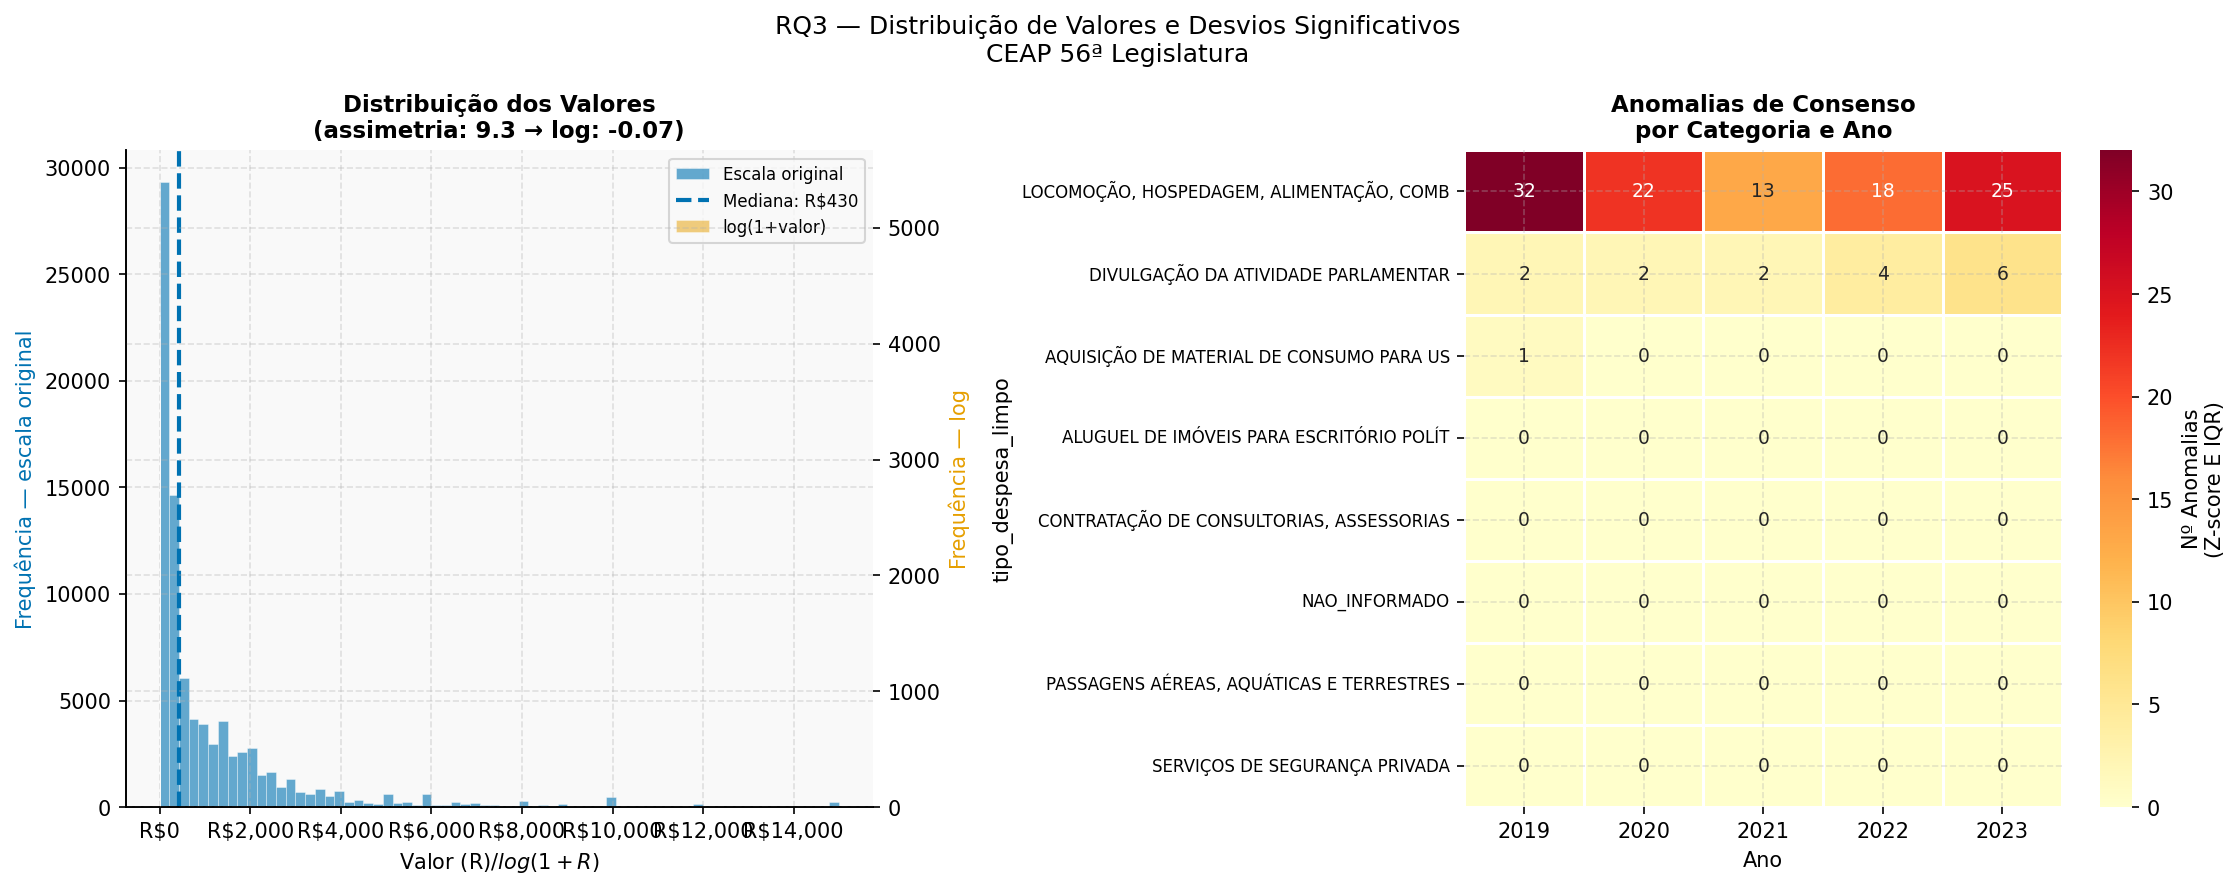

In [9]:
fig4, stats4 = plot_rq3(df, FIGURES_DIR)
eda_log['rq3'] = stats4
plt.show()

### 4.8 Top 20 candidatos a anomalia

Registros com `iqr_outlier_flag = True`, ordenados pelo Z-score absoluto. `anomalia_consenso = True` indica que passou nos **dois** filtros.

In [10]:
top_anom = (
    df[df['iqr_outlier_flag'] == True]
    [[
        'nome_senador_limpo', 'tipo_despesa_limpo',
        'nome_fornecedor_limpo', 'data_despesa',
        'valor_limpo', 'zscore_categoria', 'anomalia_consenso'
    ]]
    .sort_values('zscore_categoria', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(
    top_anom.style
    .format({'valor_limpo': 'R${:,.2f}', 'zscore_categoria': '{:.3f}'})
    .background_gradient(subset=['valor_limpo'],      cmap='Reds')
    .background_gradient(subset=['zscore_categoria'], cmap='Oranges')
)

eda_log['rq3_top20'] = top_anom.to_dict('records')

,nome_senador_limpo,tipo_despesa_limpo,nome_fornecedor_limpo,data_despesa,valor_limpo,zscore_categoria,anomalia_consenso
0,DAVI ALCOLUMBRE,"LOCOMOÇÃO, HOSPEDAGEM, ALIMENTAÇÃO, COMBUSTÍVEIS E LUBRIFICANTES",AEROTOP TÁXI AÉREO LTDA - EPP,2019-03-12 00:00:00,"R$66,730.00",4.123,True
1,CID GOMES,"LOCOMOÇÃO, HOSPEDAGEM, ALIMENTAÇÃO, COMBUSTÍVEIS E LUBRIFICANTES",TAM AVIAÇÃO EXECUTIVA E TAXI AÉREO,2021-03-30 00:00:00,"R$54,552.00",3.979,True
2,STYVENSON VALENTIM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,PLANALTO MARKETING & PUBLICIDADE LTDA,2023-12-13 00:00:00,"R$83,000.00",3.820,True
3,STYVENSON VALENTIM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,44.180.796 TATIANE DA COSTA,2023-12-12 00:00:00,"R$80,000.00",3.784,True
4,STYVENSON VALENTIM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,ANDERSON AQUINO DE ALENCAR 03861424169,2023-12-12 00:00:00,"R$77,000.00",3.747,True
5,SÉRGIO PETECÃO,"LOCOMOÇÃO, HOSPEDAGEM, ALIMENTAÇÃO, COMBUSTÍVEIS E LUBRIFICANTES",ORTIZ TAXI AEREO LTDA,2021-11-25 00:00:00,"R$39,000.00",3.740,True
6,STYVENSON VALENTIM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,RADIO NATAL REIS MAGOS LTDA EPP,2022-12-19 00:00:00,"R$72,923.16",3.695,True
7,ROGÉRIO CARVALHO,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,LF LOCAÇÕES DE EQUIPAMENTOS E FILMAGENS LTDA. ME,2020-12-02 00:00:00,"R$72,000.00",3.682,True
8,MECIAS DE JESUS,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,FORBRAS RORAIMA LTDA,2022-07-05 00:00:00,"R$70,000.00",3.655,True
9,TELMÁRIO MOTA,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,GRÁFICA MAXTER LTDA.,2022-10-25 00:00:00,"R$70,000.00",3.655,True


---
## RQ4: Como os padrões de gasto evoluíram ao longo dos 5 anos?

### 4.9 Série anual com variação YoY

`yoy_pct` = variação percentual do total em relação ao ano anterior. Verde = crescimento; vermelho = queda.

In [11]:
serie = rq4_serie_temporal(df)
eda_log['rq4_serie'] = serie.to_dict('records')

display(
    serie.style.format({
        'total'  : 'R${:,.0f}',
        'media'  : 'R${:,.2f}',
        'mediana': 'R${:,.2f}',
        'yoy_pct': '{:+.1f}%',
    })
    .background_gradient(subset=['yoy_pct'], cmap='RdYlGn', vmin=-30, vmax=30)
)

,ano,total,n,media,mediana,yoy_pct
0,2019,"R$25,247,729",21634,"R$1,167.04",R$345.83,+nan%
1,2020,"R$20,414,924",14090,"R$1,448.89",R$389.93,-19.1%
2,2021,"R$25,020,324",16827,"R$1,486.92",R$500.00,+22.6%
3,2022,"R$27,323,316",16805,"R$1,625.90",R$481.44,+9.2%
4,2023,"R$29,085,484",18755,"R$1,550.81",R$442.00,+6.5%


### Figura RQ4: Série mensal + barras anuais

**Painel superior:** linha do gasto mensal ao longo dos 60 meses. Faixa vermelha = pandemia (mar/2020–abr/2022). Linha tracejada laranja = início de 2022 (eleições).

**Painel inferior:** barras anuais com total em R$ e variação YoY dentro.

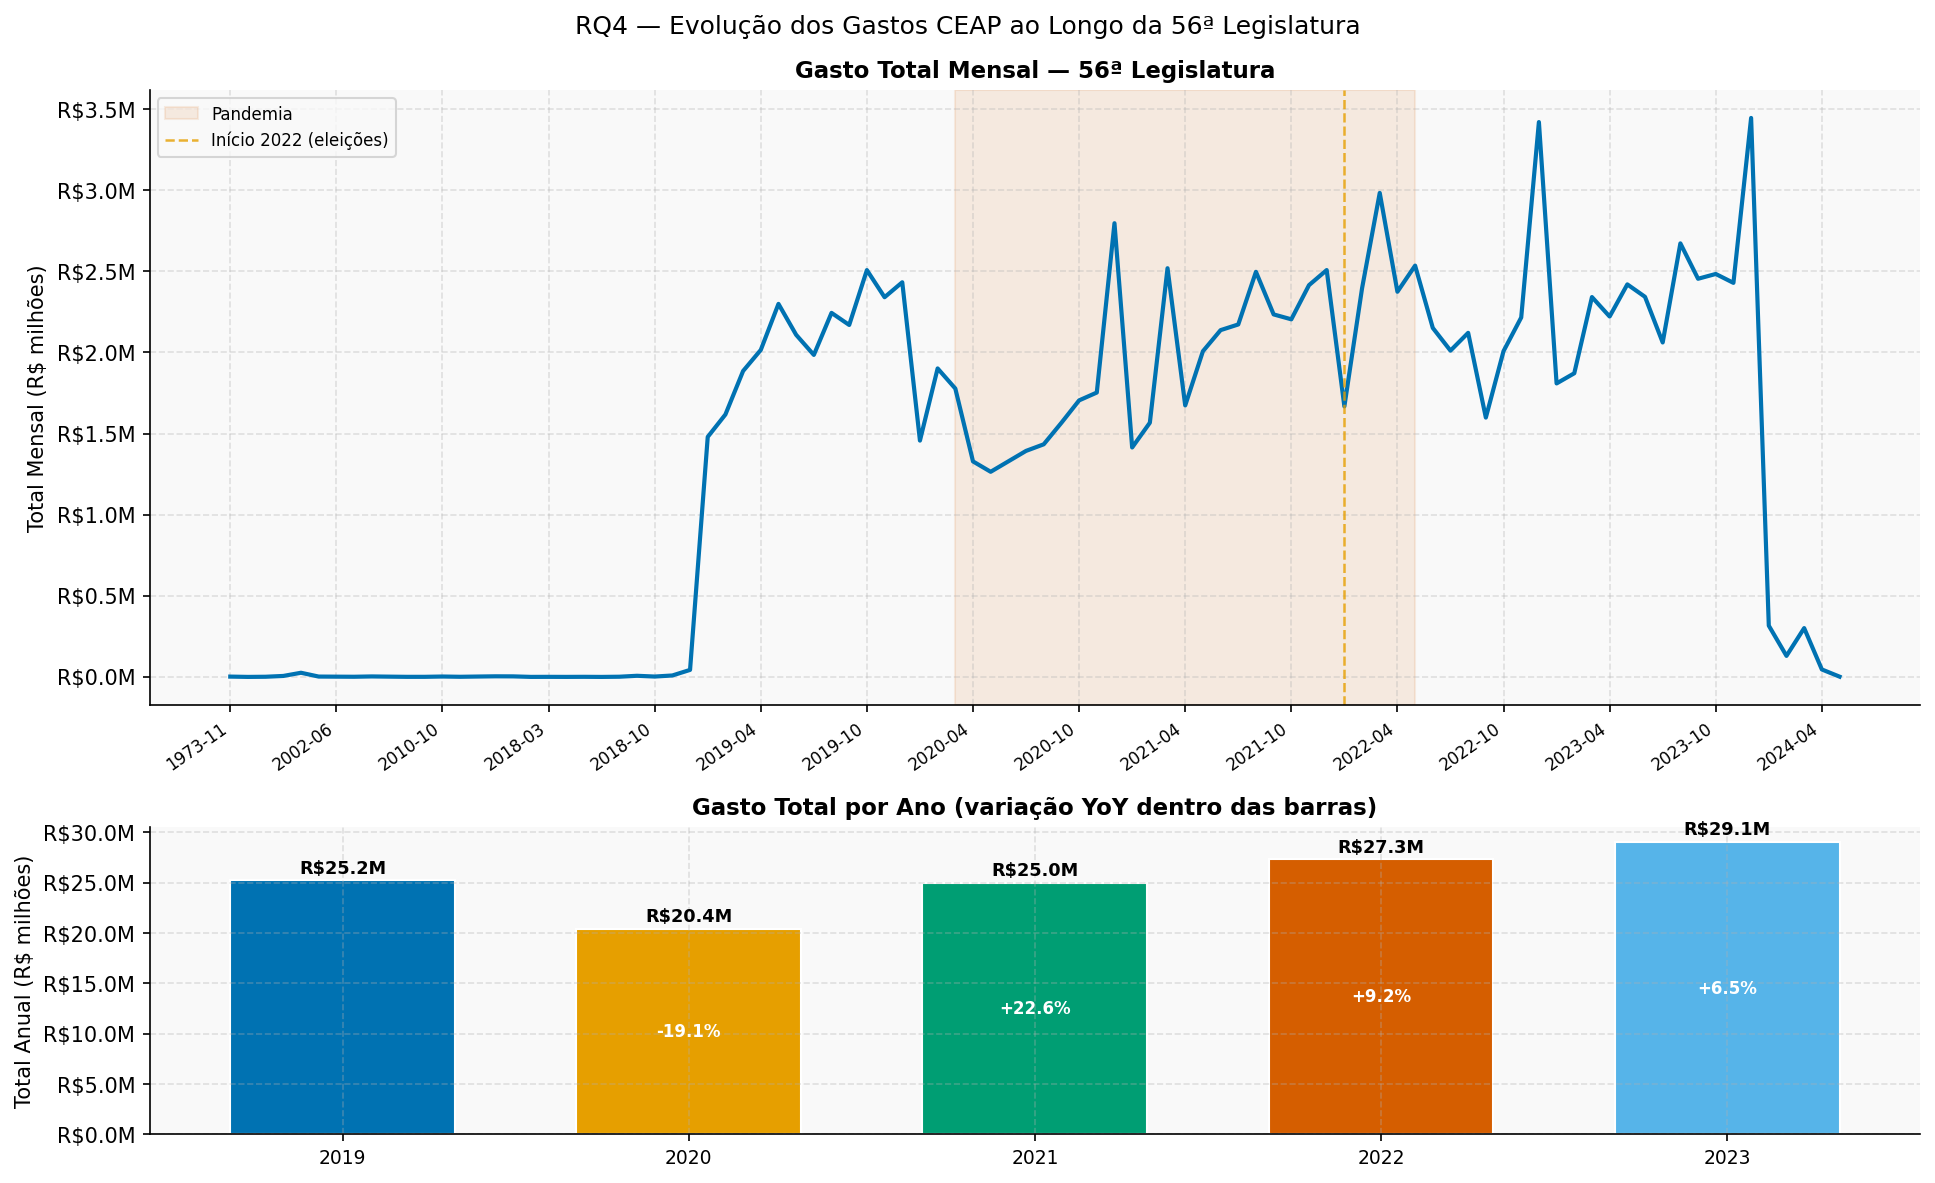

In [12]:
fig5, stats5 = plot_rq4(df, FIGURES_DIR)
eda_log['rq4'] = stats5
plt.show()

### 4.10 Análise do impacto da pandemia

| Período | Marco legal |
|---|---|
| Pré-pandemia | Até fevereiro de 2020 |
| Pandemia | Março de 2020 a abril de 2022 |
| Pós-pandemia | A partir de maio de 2022 |

Encerramento da ESPIN: **Portaria GM/MS nº 913, de 22 de abril de 2022**.

In [13]:
tab_pan = rq4_pandemia(df)
eda_log['rq4_pandemia'] = tab_pan.to_dict('records')

display(
    tab_pan.style.format({
        'total'      : 'R${:,.0f}',
        'media'      : 'R${:,.2f}',
        'mediana'    : 'R${:,.2f}',
        'percentual' : '{:.1f}%',
    })
    .background_gradient(subset=['total'], cmap='RdYlGn')
)

,periodo_pandemia,total,n_registros,media,mediana,percentual
0,pre_pandemia,"R$28,566,493",24682,"R$1,157.38",R$345.39,22.5%
1,pandemia,"R$51,117,442",33822,"R$1,511.37",R$469.27,40.2%
2,pos_pandemia,"R$47,406,080",29604,"R$1,601.34",R$452.48,37.3%


**Painel esquerdo:** boxplot do valor por nota fiscal em cada período — revela se o *ticket típico* mudou, independente do volume total.

**Painel direito:** total gasto em R$ milhões por período, com percentual do total da legislatura.

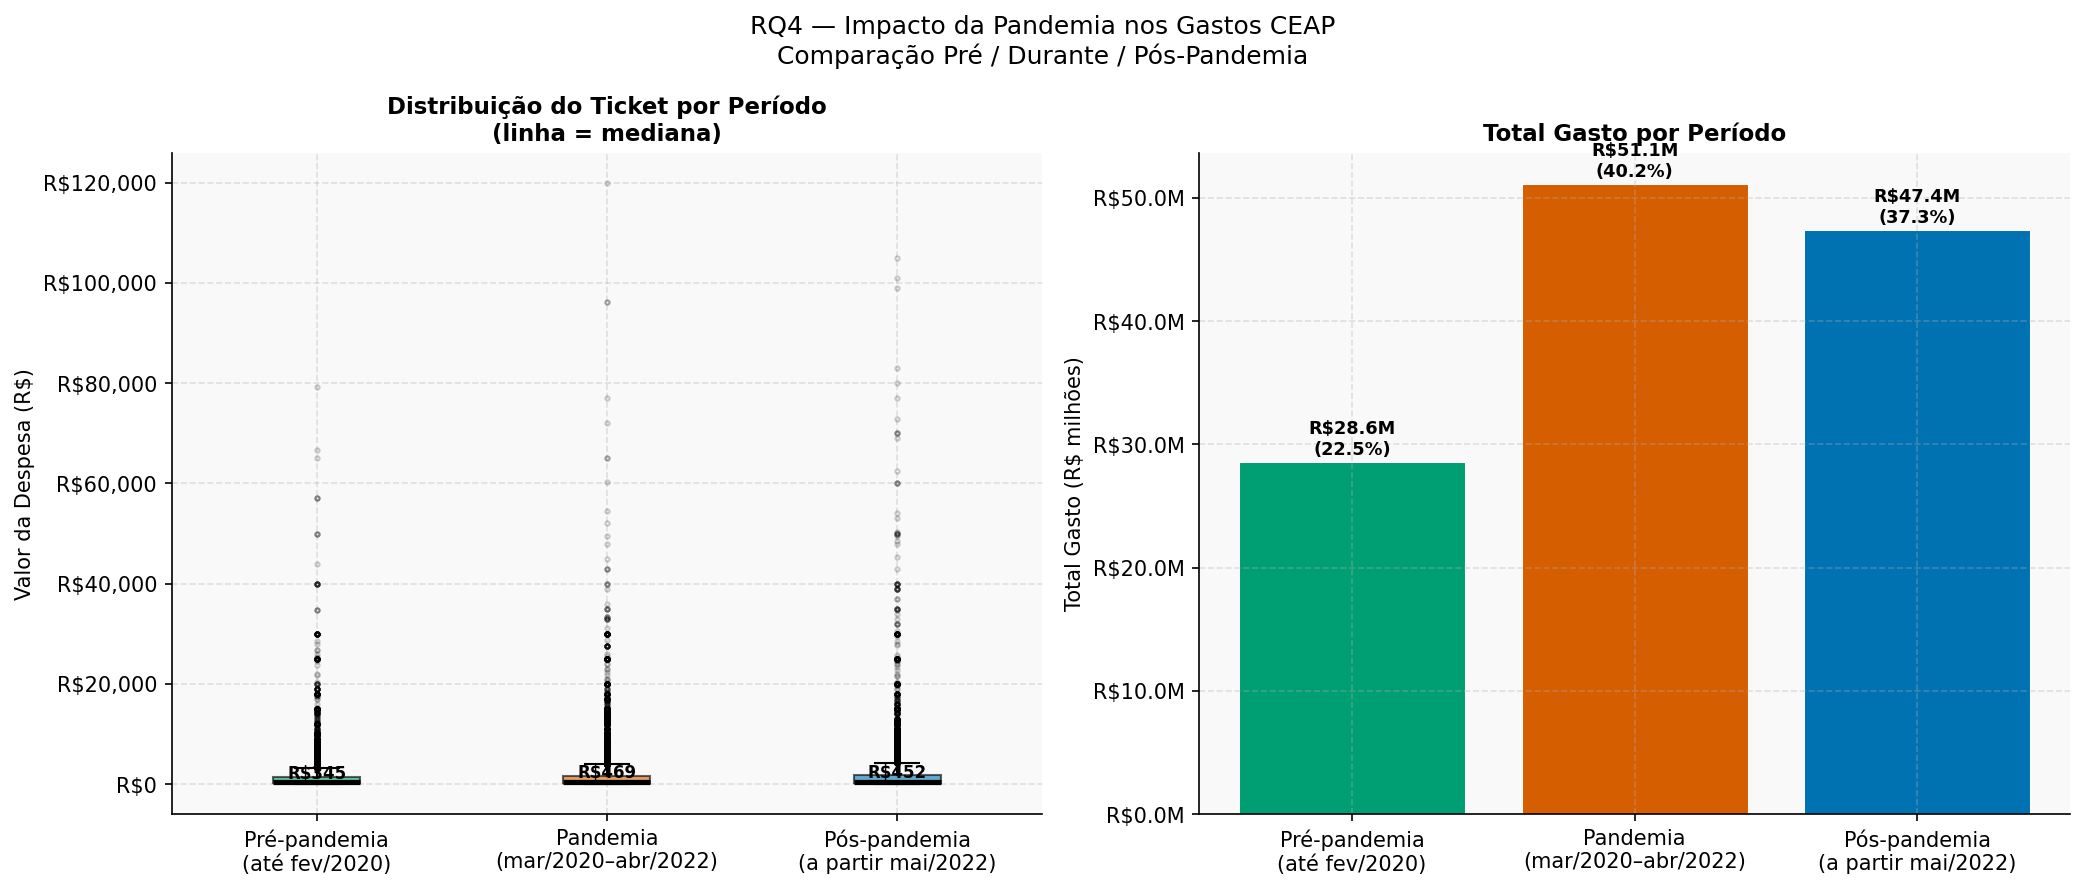

In [14]:
fig6, stats6 = plot_rq4_pandemia(df, FIGURES_DIR)
eda_log['rq4_pandemia_fig'] = stats6
plt.show()

### 4.11 Sazonalidade: Gasto por mês e ano

Cada célula = total gasto naquele mês/ano em R$ milhões.

**Linha consistentemente escura** em todos os anos = sazonalidade real (padrão que se repete independente do ano). **Célula isolada** muito mais escura que o restante da linha = evento pontual naquele mês específico.

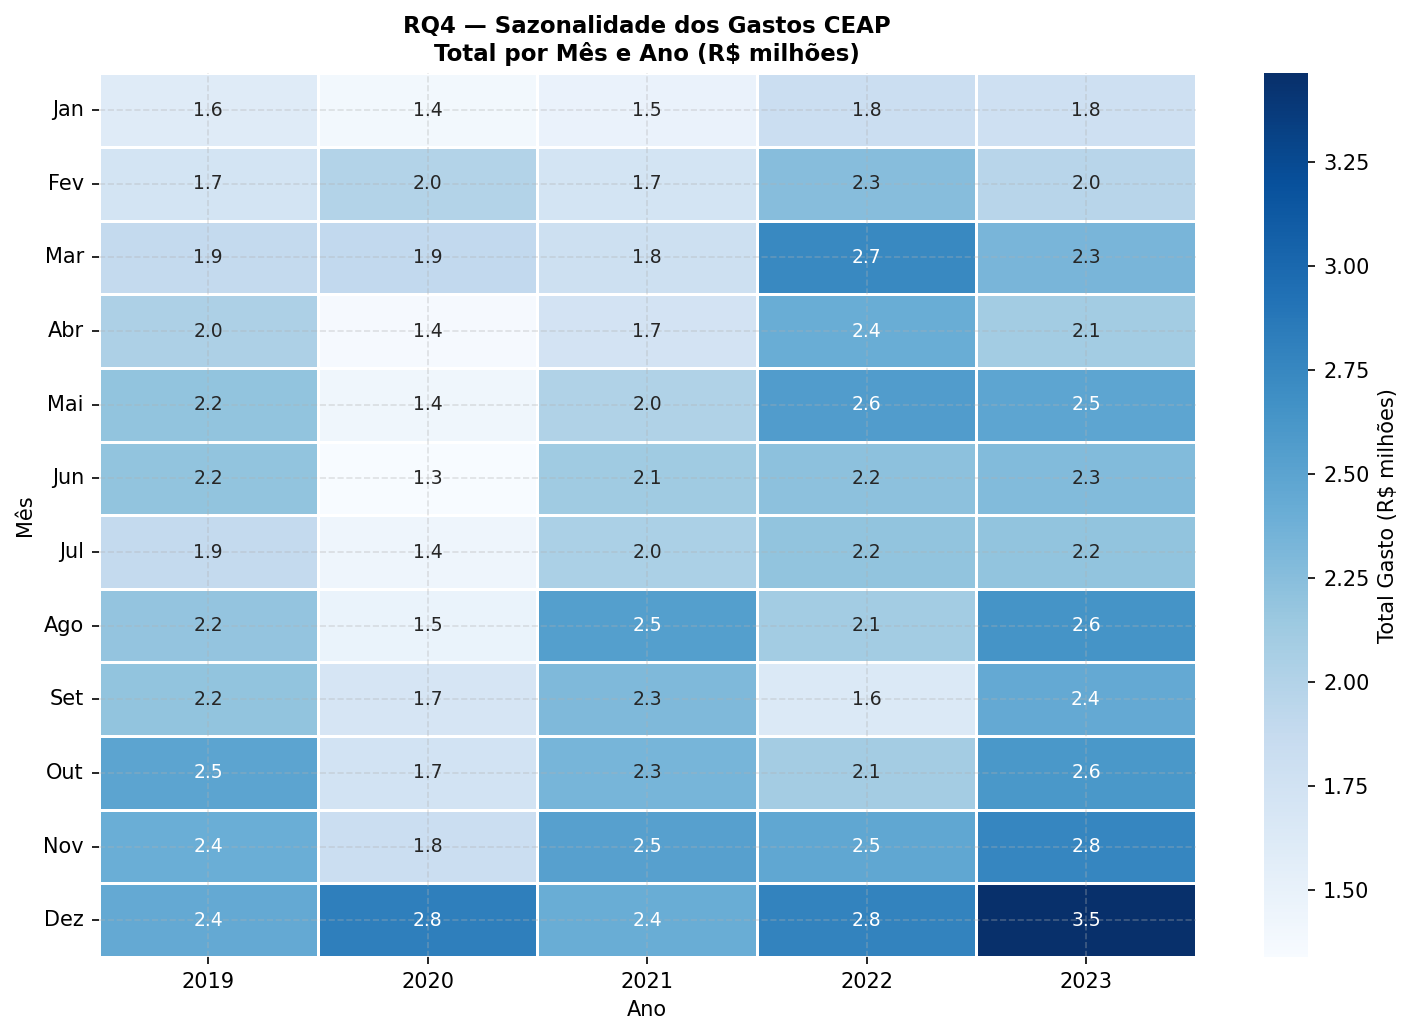

In [15]:
fig7, stats7 = plot_rq4_sazonalidade(df, FIGURES_DIR)
eda_log['rq4_sazonalidade'] = 'ver figures/rq4_sazonalidade.png'
plt.show()

---
## 4.12 Salvar log de EDA

In [16]:
import datetime, numpy as np

def _serial(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Timestamp):   return obj.isoformat()
    if pd.isna(obj):                    return None
    raise TypeError(f'Tipo nao serializavel: {type(obj)}')

eda_log['metadata'] = {
    'timestamp'   : datetime.datetime.now().isoformat(),
    'n_registros' : int(len(df)),
    'n_senadores' : int(df['cod_senador'].nunique()),
    'gasto_total' : float(df['valor_limpo'].sum()),
    'figuras_em'  : str(FIGURES_DIR),
}

log_path = LOGS_DIR / 'eda_stats.json'
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(eda_log, f, ensure_ascii=False, indent=2, default=_serial)

print(f'Log salvo: {log_path}')
print('Figuras geradas:')
for p in sorted(FIGURES_DIR.glob('rq*.png')):
    print(f'  {p.name}')

Log salvo: C:\Users\olive\OneDrive\Documentos\UnB\CE\Artigo\ceap-56-legislatura\logs\eda_stats.json
Figuras geradas:
  rq1_categorias.png
  rq2_senadores.png
  rq2_top_fornecedores.png
  rq3_anomalias.png
  rq4_pandemia.png
  rq4_sazonalidade.png
  rq4_serie_temporal.png
